 # Evaluación Completa con Texto Real y Métricas

In [4]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.saving import load_model
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import seaborn as sns
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to C:\Users\Gerard/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

 ## 1. Configuración Inicial y Carga de Modelo

In [5]:
# Configuración de rutas
BASE_DIR = Path(r"C:\Users\Gerard\Desktop\VISUAL_STUDIO\Descrpicion_Automatica_Imagenes")
MODEL_PATH = BASE_DIR / "final_model.keras"
VOCAB_PATH = BASE_DIR / "vocab_resources.pkl"
IMAGE_DIR = BASE_DIR / "Flickr8k" / "Flicker8k_Dataset"
DESCRIPTIONS_FILE = BASE_DIR / "Flickr8k" / "Flickr8k.token.txt"

# Clase de atención personalizada
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)
        self.units = units

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# Cargar modelo y vocabulario
model = load_model(MODEL_PATH, custom_objects={'BahdanauAttention': BahdanauAttention})
with open(VOCAB_PATH, 'rb') as f:
    vocab_data = pickle.load(f)
    word_to_idx = vocab_data['word_to_idx']
    idx_to_word = vocab_data['idx_to_word']
    max_seq_length = vocab_data['max_seq_length']

# Cargar VGG16 para extracción de características
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
vgg.trainable = False
print("✅ Modelos cargados correctamente")


C:\Users\Gerard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\layer.py:391: UserWarning: `build()` was called on layer 'bahdanau_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Users\Gerard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


✅ Modelos cargados correctamente


 ## 2. Función `generate_caption_final` Completa

In [6]:
def generate_caption_final(image_path):
    """Genera descripciones para imágenes con el flujo completo corregido"""
    try:
        # 1. Preprocesar imagen
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)
        
        # 2. Extraer características con VGG16
        features = vgg.predict(img_array, verbose=0)
        features = tf.keras.layers.GlobalAveragePooling2D()(features).numpy()
        
        # 3. Generar descripción
        caption = []
        input_seq = [word_to_idx['<start>']]
        
        for _ in range(max_seq_length):
            # Preparar secuencia de entrada (asegurando longitud correcta)
            seq = pad_sequences([input_seq], maxlen=max_seq_length-1, padding='post')
            
            # Predecir
            preds = model.predict({
                'image_features': features,
                'caption_input': seq
            }, verbose=0)[0]
            
            # Obtener siguiente palabra
            pred_idx = np.argmax(preds)
            word = idx_to_word.get(pred_idx, '<unk>')
            
            if word == '<end>':
                break
                
            caption.append(word)
            input_seq.append(pred_idx)
        
        # Post-procesamiento
        caption = ' '.join(caption).capitalize()
        if len(caption) > 0 and caption[-1] not in {'.', '!', '?'}:
            caption += '.'
            
        return caption
    
    except Exception as e:
        print(f"Error procesando {image_path}: {str(e)}")
        return "No se pudo generar descripción"


 ## 3. Carga de Descripciones Reales

In [7]:
def load_reference_descriptions(descriptions_file):
    """Carga todas las descripciones reales del archivo"""
    descriptions = {}
    with open(descriptions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
            img_id, desc = line.split('\t')
            img_id = img_id.split('.')[0]
            if img_id not in descriptions:
                descriptions[img_id] = []
            descriptions[img_id].append(desc.lower())
    return descriptions

reference_descriptions = load_reference_descriptions(DESCRIPTIONS_FILE)
print(f"✔ Descripciones cargadas para {len(reference_descriptions)} imágenes")


✔ Descripciones cargadas para 8092 imágenes


 ## 4. Evaluación Completa con Métricas

In [8]:
def evaluate_with_metrics(image_paths, num_samples=5):
    """Evalúa el modelo con métricas cuantitativas y cualitativas"""
    results = []
    smoothie = SmoothingFunction().method4
    
    for img_path in image_paths[:num_samples]:
        img_id = img_path.stem
        ref_descriptions = reference_descriptions.get(img_id, [])
        
        if not ref_descriptions:
            continue
            
        # Generar descripción
        gen_caption = generate_caption_final(str(img_path))
        
        # Tokenizar para métricas
        gen_tokens = word_tokenize(gen_caption.lower())
        ref_tokens_list = [word_tokenize(ref.lower()) for ref in ref_descriptions]
        
        # Calcular métricas
        bleu1 = sentence_bleu(ref_tokens_list, gen_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu4 = sentence_bleu(ref_tokens_list, gen_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        word_overlap = len(set(gen_tokens) & set().union(*[set(t) for t in ref_tokens_list])) / len(set(gen_tokens)) if gen_tokens else 0
        
        results.append({
            'image_id': img_id,
            'generated': gen_caption,
            'references': ref_descriptions,
            'bleu1': bleu1,
            'bleu4': bleu4,
            'word_overlap': word_overlap,
            'length': len(gen_tokens)
        })
        
        # Visualización
        plt.figure(figsize=(15, 5))
        
        # Imagen
        plt.subplot(1, 3, 1)
        img = load_img(str(img_path))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Imagen: {img_id}")
        
        # Descripción generada
        plt.subplot(1, 3, 2)
        plt.text(0.1, 0.5, f"Generado:\n{gen_caption}", fontsize=10)
        plt.axis('off')
        
        # Descripciones reales
        plt.subplot(1, 3, 3)
        plt.text(0.1, 0.5, "Referencias:\n" + "\n".join(f"- {ref}" for ref in ref_descriptions[:3]), fontsize=9)
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return pd.DataFrame(results)


 ## 5. Ejecución y Visualización de Resultados

C:\Users\Gerard\AppData\Local\Temp\ipykernel_21484\188622269.py:55: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


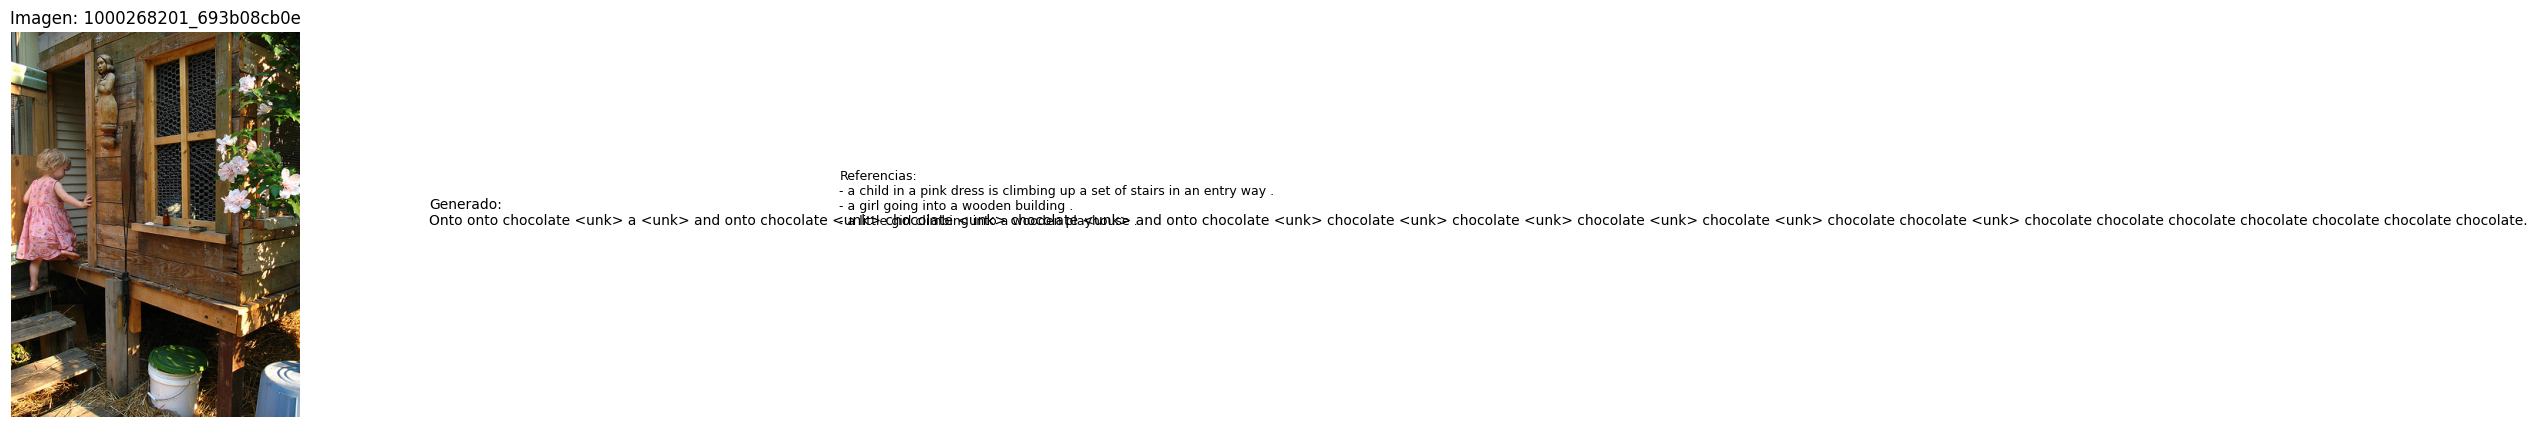

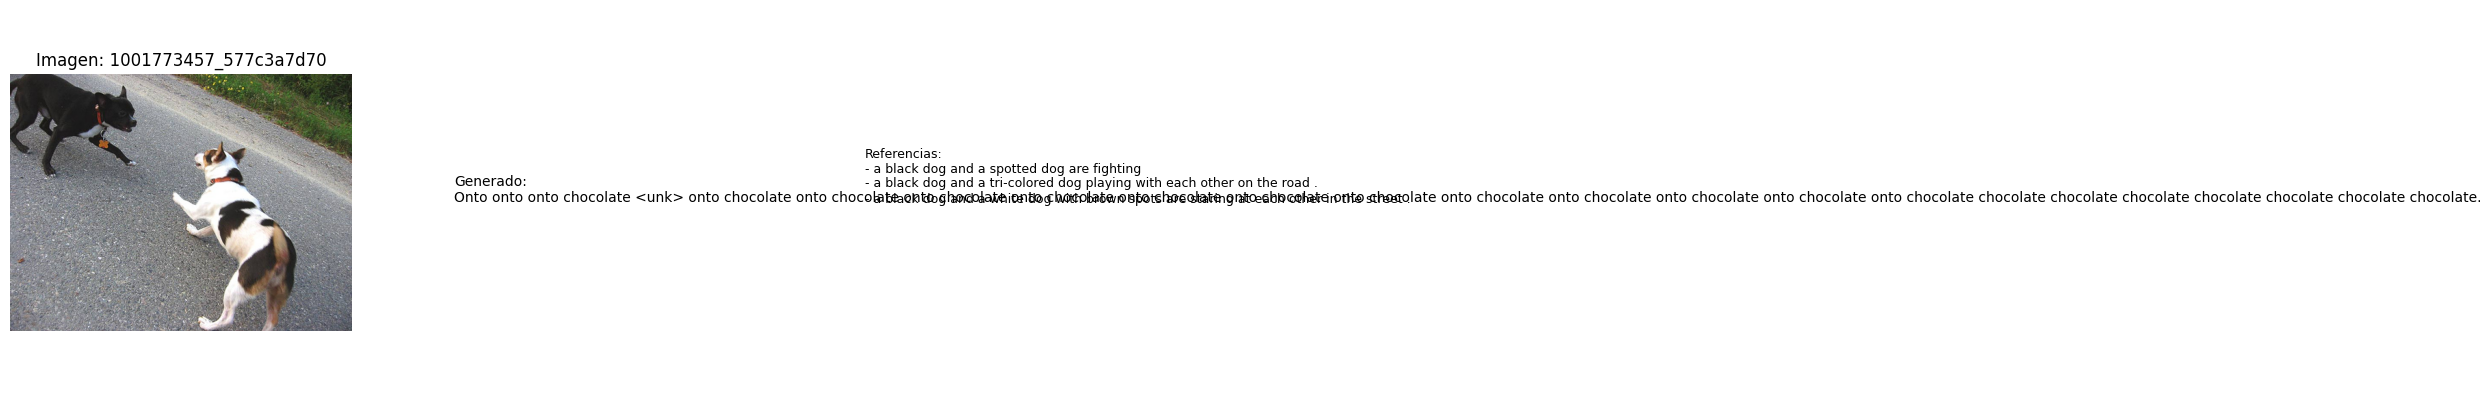

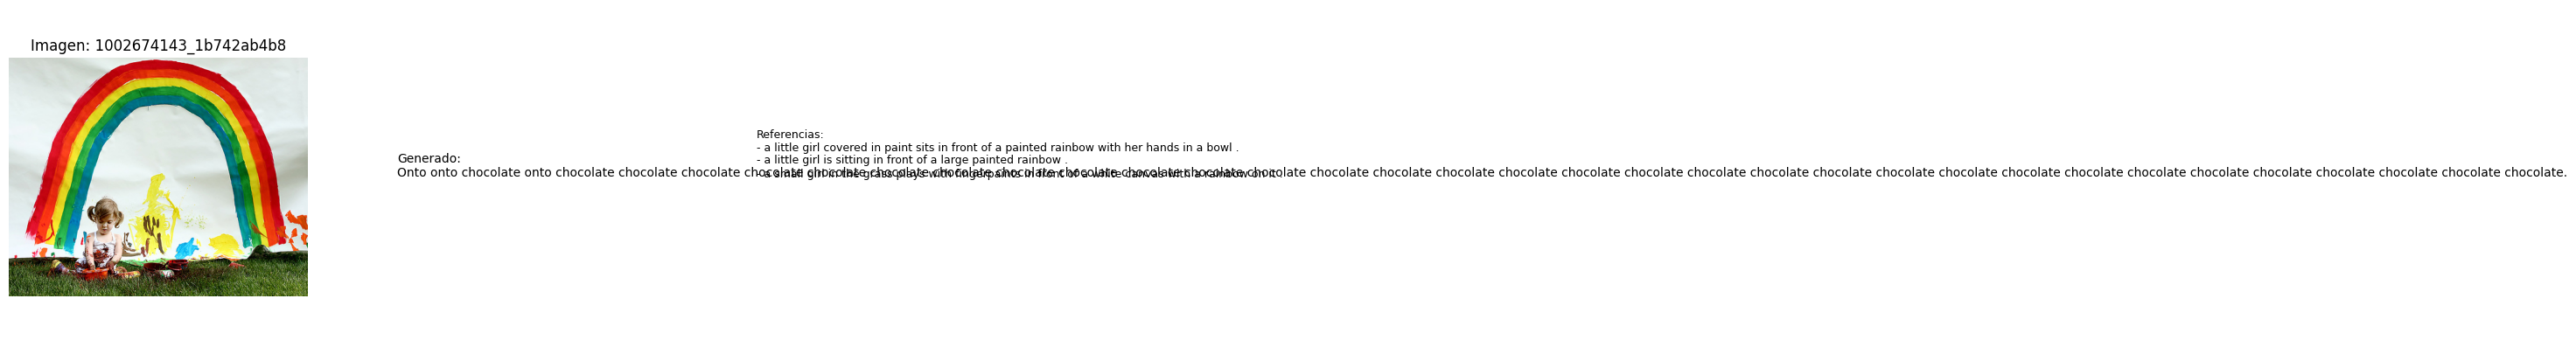

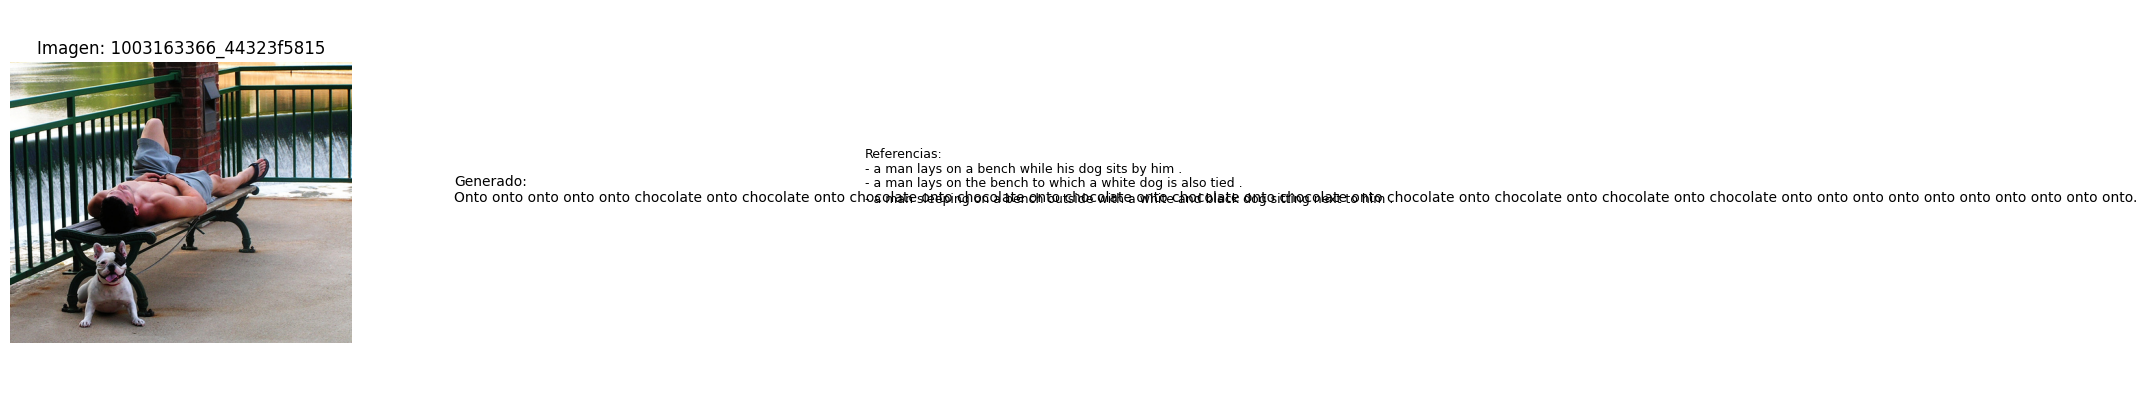

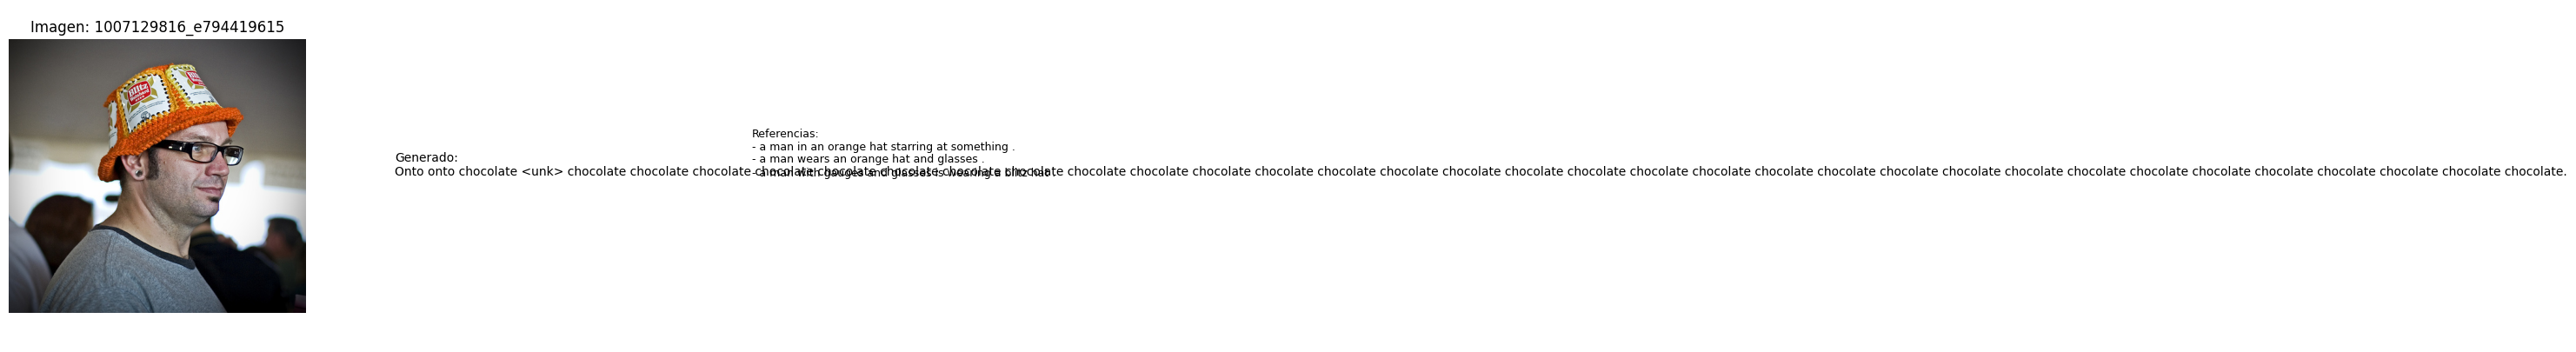


📊 Métricas Promedio:
BLEU-1: 0.028
BLEU-4: 0.007
Superposición de palabras: 0.250
Longitud promedio: 42.2 palabras


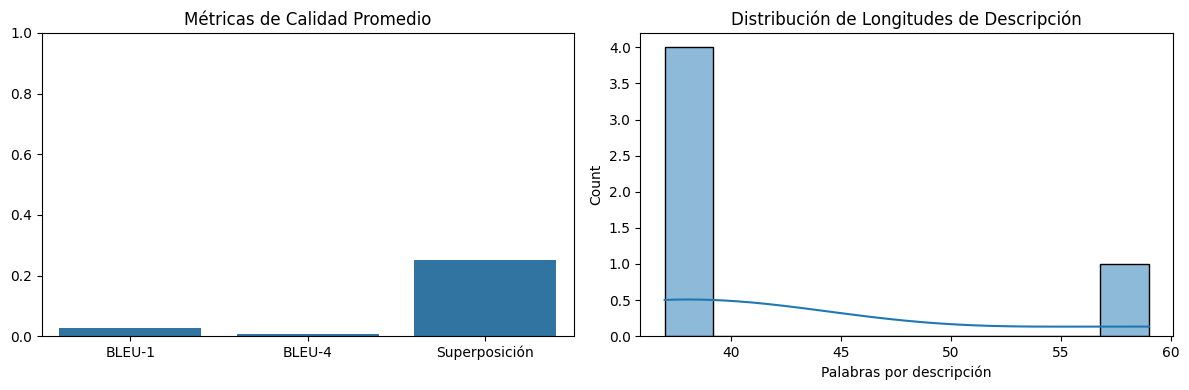

In [9]:
# Seleccionar imágenes para evaluación
image_files = list(IMAGE_DIR.glob('*.jpg'))[:10]  # Primeras 10 imágenes

# Ejecutar evaluación
results_df = evaluate_with_metrics(image_files)

# Mostrar métricas agregadas
print("\n📊 Métricas Promedio:")
print(f"BLEU-1: {results_df['bleu1'].mean():.3f}")
print(f"BLEU-4: {results_df['bleu4'].mean():.3f}")
print(f"Superposición de palabras: {results_df['word_overlap'].mean():.3f}")
print(f"Longitud promedio: {results_df['length'].mean():.1f} palabras")

# Gráficos finales
plt.figure(figsize=(12, 4))

# Métricas de calidad
plt.subplot(1, 2, 1)
sns.barplot(x=['BLEU-1', 'BLEU-4', 'Superposición'], 
            y=[results_df['bleu1'].mean(), results_df['bleu4'].mean(), results_df['word_overlap'].mean()])
plt.ylim(0, 1)
plt.title('Métricas de Calidad Promedio')

# Distribución de longitudes
plt.subplot(1, 2, 2)
sns.histplot(results_df['length'], bins=10, kde=True)
plt.title('Distribución de Longitudes de Descripción')
plt.xlabel('Palabras por descripción')

plt.tight_layout()
plt.show()


 ## 6. Análisis de Errores

In [10]:
# Identificar ejemplos con mejor y peor desempeño
best_idx = results_df['bleu4'].idxmax()
worst_idx = results_df['bleu4'].idxmin()

print("\n🏆 Mejor Resultado (BLEU-4 más alto):")
print(f"Imagen: {results_df.loc[best_idx, 'image_id']}")
print(f"BLEU-4: {results_df.loc[best_idx, 'bleu4']:.3f}")
print(f"Descripción generada: {results_df.loc[best_idx, 'generated']}")
print(f"Referencia real: {results_df.loc[best_idx, 'references'][0]}")

print("\n⚠️ Peor Resultado (BLEU-4 más bajo):")
print(f"Imagen: {results_df.loc[worst_idx, 'image_id']}")
print(f"BLEU-4: {results_df.loc[worst_idx, 'bleu4']:.3f}")
print(f"Descripción generada: {results_df.loc[worst_idx, 'generated']}")
print(f"Referencia real: {results_df.loc[worst_idx, 'references'][0]}")


🏆 Mejor Resultado (BLEU-4 más alto):
Imagen: 1002674143_1b742ab4b8
BLEU-4: 0.008
Descripción generada: Onto onto chocolate onto chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate chocolate.
Referencia real: a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .

⚠️ Peor Resultado (BLEU-4 más bajo):
Imagen: 1000268201_693b08cb0e
BLEU-4: 0.006
Descripción generada: Onto onto chocolate <unk> a <unk> and onto chocolate <unk> chocolate <unk> chocolate <unk> and onto chocolate <unk> chocolate <unk> chocolate <unk> chocolate <unk> chocolate <unk> chocolate chocolate <unk> chocolate chocolate chocolate chocolate chocolate chocolate chocolate.
Referencia real: a child in a pink dress is climbing up a s